# Propensity Score Matching — Groupon Deals

Estimates the causal effect of a minimum order requirement on deal revenue
using Propensity Score Matching.

| | |
|---|---|
| **Treatment** | `treatment` — 1 if deal has a minimum order requirement, 0 otherwise |
| **Outcome** | `revenue` — total revenue of the deal ($) |
| **Dataset** | Groupon deals collected by Gang Wang (Wang et al.) |

In [157]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

In [158]:
df = pd.read_csv(Path("../data/raw/groupon.csv"))

# Feature extraction

In [159]:
# clean data
df['start_date'] = pd.to_datetime(df['start_date'])
df['start_date'].describe()

count                           710
mean     2012-03-13 08:22:59.154929
min             2011-09-23 00:00:00
25%             2011-12-13 06:00:00
50%             2012-02-16 00:00:00
75%             2012-06-08 18:00:00
max             2012-07-31 00:00:00
Name: start_date, dtype: object

In [160]:
last_date = df.start_date.max()
df['recency'] = (last_date - df['start_date']).dt.days

In [161]:
df['recency_tercile'] = pd.qcut(df['recency'], q=3, labels=['Recent', 'Mid-age', 'Old'])
df.groupby('recency_tercile')['treatment'].mean()

recency_tercile
Recent     0.012552
Mid-age    0.042553
Old        0.860169
Name: treatment, dtype: float64

In [162]:
TREATMENT  = "treatment"
OUTCOME    = "revenue"
COVARIATES = ["prom_length", "price", "discount_pct", "coupon_duration", "featured", "limited_supply", "fb_likes"]

print(f"Shape     : {df.shape}")
print(f"Treated   : {df[TREATMENT].sum():.0f}")
print(f"Control   : {(1 - df[TREATMENT]).sum():.0f}")
df.head()

Shape     : (710, 15)
Treated   : 216
Control   : 494


,deal_id,start_date,min_req,treatment,prom_length,price,discount_pct,coupon_duration,featured,limited_supply,fb_likes,quantity_sold,revenue,recency,recency_tercile
0,heli-flights,2011-09-23,10,1,4,99,51,185,1,1,290,540,53460,312,Old
1,gl-champion-series-tennis-electric-factory,2011-09-23,20,1,2,95,41,9,0,1,43,190,18050,312,Old
2,realm-of-terror-horror-experience,2011-09-23,50,1,3,25,50,38,0,1,208,380,9500,312,Old
3,newport-gourmet,2011-09-23,15,1,3,50,50,369,0,1,16,90,4500,312,Old
4,the-clayroom,2011-09-23,20,1,4,25,52,185,0,1,85,580,14500,312,Old


## compare the two groups

In [163]:
# separate control and treatment for t-test
df_control = df[df.treatment==0]
df_treatment = df[df.treatment==1]

In [164]:
# student's t-test for revenue (dependent variable)
from scipy.stats import ttest_ind

print(round(df_control['revenue'].mean(), 2), round(df_treatment['revenue'].mean(), 2))

# compare samples
_, p = ttest_ind(df_control['revenue'], df_treatment['revenue'])
print(f'p={p:.3f}')

# interpret
alpha = 0.05  # significance level
if p > alpha:
    print('same distributions/same group mean (fail to reject H0 - we do not have enough evidence to reject H0)')
else:
    print('different distributions/different group mean (reject H0)')


9720.99 12750.69
p=0.040
different distributions/different group mean (reject H0)


## compute the standardized mean difference

In [165]:
def smd(df, covariates, treatment):
    """
    Compute standardized mean differences for a list of covariates.

    For each covariate, calculates:
        SMD = (mean_treated - mean_control) / pooled_SD

    where pooled_SD = sqrt((var_treated + var_control) / 2)

    Returns a DataFrame with one row per covariate showing the group means and SMD.
    """
    treated = df[df[treatment] == 1]
    control = df[df[treatment] == 0]
    rows = []

    for col in covariates:
        mt = treated[col].mean()
        mc = control[col].mean()
        pooled_sd = np.sqrt((treated[col].var() + control[col].var()) / 2)
        smd_val = (mt - mc) / pooled_sd if pooled_sd > 0 else np.nan
        rows.append({"covariate": col, "mean_treated": mt, "mean_control": mc, "smd": smd_val})

    return pd.DataFrame(rows).set_index("covariate").sort_values("smd", key=abs, ascending=False)

balance_pre = smd(df, COVARIATES, TREATMENT)
balance_pre


,mean_treated,mean_control,smd
covariate,,,
prom_length,3.379630,3.809717,-0.328324
coupon_duration,131.842593,95.941296,0.282704
price,29.421296,37.870445,-0.240651
fb_likes,113.203704,77.941296,0.223491
limited_supply,0.777778,0.852227,-0.192279
featured,0.143519,0.105263,0.115908
discount_pct,53.263889,52.973684,0.036996


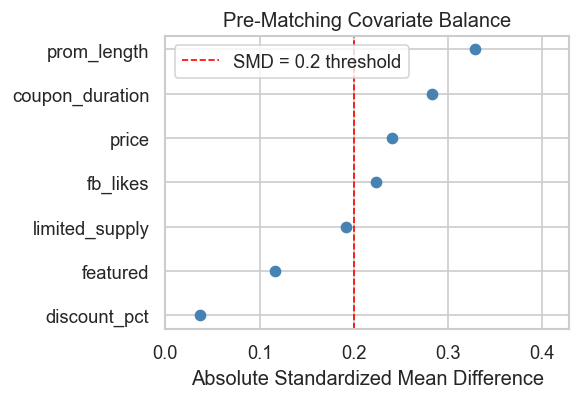

In [166]:
fig, ax = plt.subplots(figsize=(5, len(COVARIATES) * 0.5))

abs_smd = balance_pre["smd"].abs().sort_values()

ax.scatter(abs_smd.values, abs_smd.index, color="steelblue", zorder=3)
ax.axvline(0.2, color="red", linestyle="--", linewidth=1, label="SMD = 0.2 threshold")
ax.set_xlabel("Absolute Standardized Mean Difference")
ax.set_title("Pre-Matching Covariate Balance")
ax.legend()
plt.xlim(0, balance_pre["smd"].abs().max() + 0.1)
plt.tight_layout()
plt.savefig('love_plot.png')

In [167]:
abs_smd.nlargest(30)

covariate
prom_length        0.328324
coupon_duration    0.282704
price              0.240651
fb_likes           0.223491
limited_supply     0.192279
featured           0.115908
discount_pct       0.036996
Name: smd, dtype: float64

## generate the model

In [168]:
formula = f"{TREATMENT} ~ {' + '.join(COVARIATES)}"

ps_model = smf.logit(formula, data=df).fit()
ps_model.summary()

Optimization terminated successfully.
         Current function value: 0.568546
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              treatment   No. Observations:                  710
Model:                          Logit   Df Residuals:                      702
Method:                           MLE   Df Model:                            7
Date:                Tue, 14 Jul 2026   Pseudo R-squ.:                 0.07464
Time:                        07:24:11   Log-Likelihood:                -403.67
converged:                       True   LL-Null:                       -436.23
Covariance Type:            nonrobust   LLR p-value:                 1.425e-11
===================================================================================
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.9673      0.684      1.414      0.157      -0.374       2.308
prom_length        -0.3783      0.078     -4.826      0.000      -0.532      -0.225
price              -0.0092      0.003     -3.025      0.002      -0.015      -0.003
discount_pct       -0.0081      0.011     -0.758      0.448      -0.029       0.013
coupon_duration     0.0036      0.001      4.256      0.000       0.002       0.005
featured            0.1992      0.259      0.769      0.442      -0.308       0.707
limited_supply     -0.3965      0.231     -1.714      0.087      -0.850       0.057
fb_likes            0.0021      0.001      3.552      0.000       0.001       0.003
===================================================================================
"""

In [169]:
# Extract predicted probabilities from the fitted model and store on the dataframe.
# model.predict() with no arguments uses the same data the model was fitted on.
# The output is each person's estimated probability of having quit smoking,
# given their observed covariates — this is their propensity score.
df["propensity_score"] = ps_model.predict()

# Summarise the score distribution separately for each group.
# We want to see: (1) do the means differ? (2) how wide is each distribution?
# A well-fitted model should assign higher scores to quitters on average.
df.groupby(TREATMENT)["propensity_score"].describe()

,count,mean,std,min,25%,50%,75%,max
treatment,,,,,,,,
0,494.0,0.274908,0.121452,0.010601,0.191085,0.260881,0.340443,0.993974
1,216.0,0.371275,0.148534,0.053955,0.274199,0.353198,0.469718,0.857240


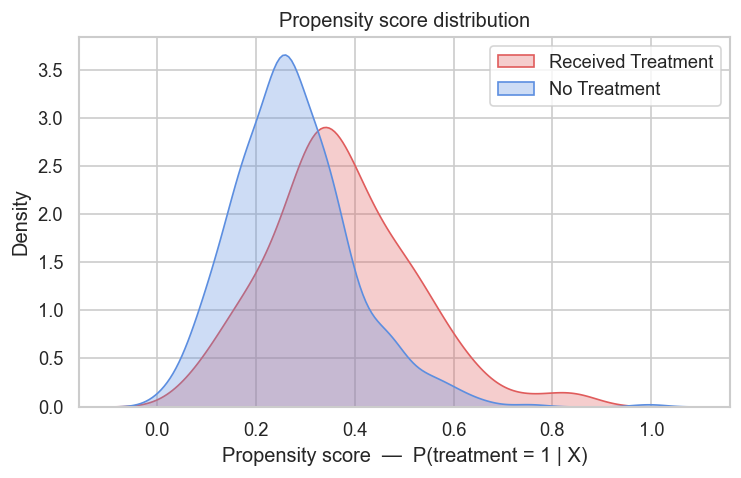

In [170]:
fig, ax = plt.subplots(figsize=(7, 4))

# Overlay KDE distributions for each group
# What we want to see: two overlapping but distinct humps — enough separation for scores
# to be doing useful work, enough overlap for valid matches to exist
for val, label, color in [(1, "Received Treatment", "#e05c5c"), (0, "No Treatment", "#5c8ee0")]:
    sns.kdeplot(df[df[TREATMENT] == val]["propensity_score"], ax=ax, label=label, color=color, fill=True, alpha=0.3)

ax.set_xlabel("Propensity score  —  P(treatment = 1 | X)")
ax.set_title("Propensity score distribution")
ax.legend()
plt.show()

In [171]:
ps_treated = df[df[TREATMENT] == 1]["propensity_score"]
ps_control = df[df[TREATMENT] == 0]["propensity_score"]

# Common support = the intersection of both score ranges
# overlap_min: the highest minimum (below this, only controls exist)
# overlap_max: the lowest maximum (above this, only treated units exist)
overlap_min = max(ps_treated.min(), ps_control.min())
overlap_max = min(ps_treated.max(), ps_control.max())

print(f"Common support region: [{overlap_min:.3f}, {overlap_max:.3f}]")
print(f"Treated units outside common support: {(ps_treated > overlap_max).sum()} of {len(ps_treated)}")
print(f"\nThese units will be excluded from matching — no comparable control exists for them.")

Common support region: [0.054, 0.857]
Treated units outside common support: 0 of 216

These units will be excluded from matching — no comparable control exists for them.


In [172]:
df['propensity_score'].std()

np.float64(0.1375335440260035)

In [173]:
# Caliper = 0.2 × SD of the propensity score (Austin, 2011)
# This is computed on the full sample before trimming to common support
caliper = 0.2 * df["propensity_score"].std()

print(f"Propensity score SD : {df['propensity_score'].std():.4f}")
print(f"Caliper (0.2 × SD) : {caliper:.4f}")
print(f"\nScore range         : [{df['propensity_score'].min():.3f}, {df['propensity_score'].max():.3f}]")
print(f"Caliper as % of range: {caliper / (df['propensity_score'].max() - df['propensity_score'].min()) * 100:.1f}%")
print(f"\nA caliper of {caliper:.4f} means two units must be within ~{caliper:.3f} propensity score")
print(f"points of each other to be considered a valid match.")

Propensity score SD : 0.1375
Caliper (0.2 × SD) : 0.0275

Score range         : [0.011, 0.994]
Caliper as % of range: 2.8%

A caliper of 0.0275 means two units must be within ~0.028 propensity score
points of each other to be considered a valid match.


In [174]:
from sklearn.neighbors import NearestNeighbors

# Separate the two pools we are matching from.
# .copy() ensures modifications (like removing matched controls) don't affect df.
treated = df[df[TREATMENT] == 1].copy()  # the 403 quitters — each needs one match
control = df[df[TREATMENT] == 0].copy()  # the 1163 non-quitters — the matching pool

print(f"Treated pool: {len(treated)}")
print(f"Control pool: {len(control)}")
print(f"\nFor every treated we will find their nearest neighbour in the control pool.")
print(f"If the distance exceeds the caliper ({caliper:.4f}), the quitter is dropped.")

Treated pool: 216
Control pool: 494

For every treated we will find their nearest neighbour in the control pool.
If the distance exceeds the caliper (0.0275), the quitter is dropped.


In [175]:
nn = NearestNeighbors(n_neighbors=1, metric="euclidean")
nn.fit(control[["propensity_score"]])

distances, indices = nn.kneighbors(treated[["propensity_score"]])

print(distances[:5])
print(indices[:5])

[[5.12979806e-05]
 [3.81785387e-04]
 [2.70201769e-04]
 [3.23071592e-04]
 [2.73350458e-04]]
[[398]
 [288]
 [333]
 [ 13]
 [ 53]]


In [176]:
import random
random.seed(42)

treated_shuffled = treated.sample(frac=1, random_state=42)
available_control = control.copy()

matched_treated = []
matched_control = []
unmatched = 0

n_neighbors = 10


for _, t_row in treated_shuffled.iterrows():
    if available_control.empty:
        unmatched += 1
        continue

    # Rebuild index on remaining available controls
    nn_iter = NearestNeighbors(n_neighbors=n_neighbors, metric="euclidean")
    nn_iter.fit(available_control[["propensity_score"]])

    dist, idx = nn_iter.kneighbors(pd.DataFrame({"propensity_score": [t_row["propensity_score"]]}))
    dist = dist[0][0]
    idx  = idx[0][0]

    if dist > caliper:
        unmatched += 1
        continue

    matched_row = available_control.iloc[idx]
    matched_treated.append(t_row)
    matched_control.append(matched_row)

    # Remove the matched control so it can't be reused
    available_control = available_control.drop(matched_row.name)

print(f"Matched pairs             : {len(matched_treated)}")
print(f"Dropped (caliper/no match): {unmatched}")

control_ids = [r.name for r in matched_control]
print(f"Unique controls used      : {len(set(control_ids))}")
print(f"Duplicates                : {len(control_ids) - len(set(control_ids))}")

Matched pairs             : 196
Dropped (caliper/no match): 20
Unique controls used      : 196
Duplicates                : 0


In [177]:
control_ids = [r.name for r in matched_control]
print(f"Total matches       : {len(control_ids)}")
print(f"Unique controls used: {len(set(control_ids))}")
print(f"Duplicates          : {len(control_ids) - len(set(control_ids))}")

Total matches       : 196
Unique controls used: 196
Duplicates          : 0


In [178]:
print("SAMPLE ATTRITION FLOW")
print("=" * 50)
print(f"  Total treated units          : 216 (100%)")
print(f"  Outside common support       :   0  (0.0%)")
print(f"  Within common support        : 216 (100%)")
print(f"    Failed caliper             :  20  (9.3%)  DROPPED")
print(f"    Matched                    : 196 (90.7%)  KEPT")
print("=" * 50)
print(f"  Total dropped                :  20  (9.3%)")
print(f"\n  ATT estimate applies to the 91% of treated")
print(f"  units that found a comparable control.")

SAMPLE ATTRITION FLOW
  Total treated units          : 216 (100%)
  Outside common support       :   0  (0.0%)
  Within common support        : 216 (100%)
    Failed caliper             :  20  (9.3%)  DROPPED
    Matched                    : 196 (90.7%)  KEPT
  Total dropped                :  20  (9.3%)

  ATT estimate applies to the 91% of treated
  units that found a comparable control.


In [179]:
df_matched = pd.concat([
    pd.DataFrame(matched_treated),
    pd.DataFrame(matched_control)
], ignore_index=True)

print(f"Matched dataset shape: {df_matched.shape}")
print(f"Treated: {df_matched[TREATMENT].sum()}")
print(f"Control: {(df_matched[TREATMENT] == 0).sum()}")

Matched dataset shape: (392, 16)
Treated: 196
Control: 196


In [180]:
balance_post = smd(df_matched, COVARIATES, TREATMENT)

balance_post

,mean_treated,mean_control,smd
covariate,,,
fb_likes,93.535714,107.678571,-0.087659
limited_supply,0.801020,0.775510,0.062314
prom_length,3.428571,3.505102,-0.060649
discount_pct,53.096939,53.459184,-0.044381
coupon_duration,122.846939,120.709184,0.018159
price,30.479592,31.015306,-0.017148
featured,0.132653,0.137755,-0.014883


## Post-matching balance

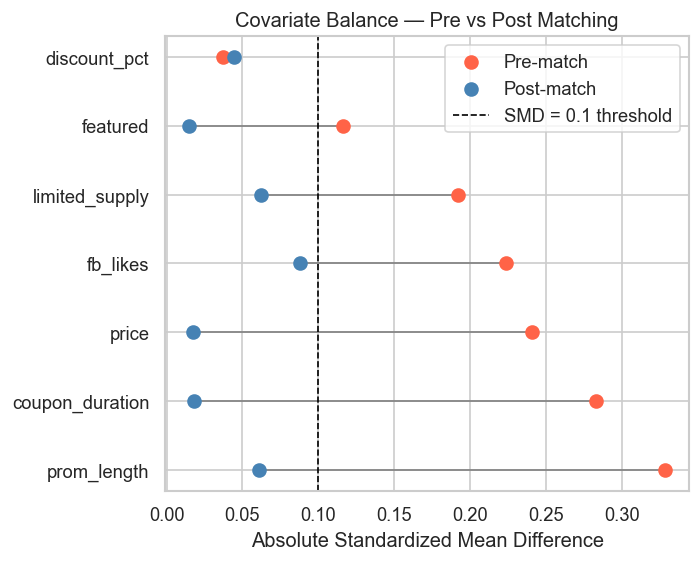

In [181]:
compare = balance_pre[["smd"]].rename(columns={"smd": "pre"}).join(
    balance_post[["smd"]].rename(columns={"smd": "post"})
).reindex(balance_pre.index)

fig, ax = plt.subplots(figsize=(6, len(COVARIATES) * 0.55 + 1))

for cov in compare.index:
    ax.plot([abs(compare.loc[cov, "pre"]), abs(compare.loc[cov, "post"])],
            [cov, cov], color="grey", linewidth=1, zorder=1)

ax.scatter(compare["pre"].abs(),  compare.index, color="tomato",    s=60, zorder=2, label="Pre-match")
ax.scatter(compare["post"].abs(), compare.index, color="steelblue", s=60, zorder=2, label="Post-match")
ax.axvline(0.1, color="black", linestyle="--", linewidth=1, label="SMD = 0.1 threshold")
ax.set_xlabel("Absolute Standardized Mean Difference")
ax.set_title("Covariate Balance — Pre vs Post Matching")
ax.legend()
plt.tight_layout()
plt.show()

## Dropped unit characterization

86% of treated units were dropped. Who are they — and does that limit what we can conclude?

In [182]:
matched_idx   = {r.name for r in matched_treated}
unmatched_idx = set(treated_shuffled.index) - matched_idx

matched_df   = df.loc[list(matched_idx)]
unmatched_df = df.loc[list(unmatched_idx)]

comparison = pd.DataFrame({
    f"Matched (n={len(matched_df)})":   matched_df[COVARIATES + [OUTCOME]].mean(),
    f"Dropped (n={len(unmatched_df)})": unmatched_df[COVARIATES + [OUTCOME]].mean(),
})
comparison["Difference"] = comparison.iloc[:, 0] - comparison.iloc[:, 1]
print(comparison.round(1))

                 Matched (n=196)  Dropped (n=20)  Difference
prom_length                  3.4             2.9         0.5
price                       30.5            19.0        11.4
discount_pct                53.1            54.9        -1.8
coupon_duration            122.8           220.0       -97.2
featured                     0.1             0.2        -0.1
limited_supply               0.8             0.6         0.3
fb_likes                    93.5           306.0      -212.4
revenue                  11418.2         25809.0    -14390.8


In [183]:
treated_outcome = df[df[TREATMENT] == 1][OUTCOME]
control_outcome  = df[df[TREATMENT] == 0][OUTCOME]
naive_att = treated_outcome.mean() - control_outcome.mean()

matched_treated_outcome = df_matched[df_matched[TREATMENT] == 1][OUTCOME]
matched_control_outcome  = df_matched[df_matched[TREATMENT] == 0][OUTCOME]
att_matched = matched_treated_outcome.mean() - matched_control_outcome.mean()

print(f"Naive ATT: ${naive_att:.2f} revenue")
print(f"PSM ATT (matched): ${att_matched:.2f} revenue")

Naive ATT: $3029.71 revenue
PSM ATT (matched): $-711.15 revenue


In [184]:
from scipy import stats

paired_diff = matched_treated_outcome.values - matched_control_outcome.values
att_matched = paired_diff.mean()
se          = paired_diff.std() / np.sqrt(len(paired_diff))
ci_low      = att_matched - 1.96 * se
ci_high     = att_matched + 1.96 * se
t_stat, p   = stats.ttest_1samp(paired_diff, 0)

print(f"Naive ATT  : ${naive_att:>10,.2f}")
print(f"PSM ATT    : ${att_matched:>10,.2f}")
print(f"95% CI     : [${ci_low:,.2f}, ${ci_high:,.2f}]")
print(f"p-value    : {p:.4f}")
print()
print("The naive estimate (+$3,030) suggests minimum order requirements boost revenue,")
print("but this is driven by selection: treated deals differ systematically from controls.")
print()
print("After matching on deal characteristics, the PSM ATT is -$711 — but the effect")
print("is not statistically significant (p=0.683, 95% CI crosses zero by a wide margin).")
print("We cannot reject the null that minimum order requirements have no effect on revenue.")
print()
print(f"CAVEAT: The 20 unmatched treated deals are outliers with very high fb_likes")
print(f"(avg 306 vs 94 for matched) and long coupon_duration (avg 220 vs 123 days).")
print(f"These high-visibility deals also earned far more revenue ($25,809 vs $11,418 avg),")
print(f"so the ATT for this narrow slice may not represent the full treated population.")

Naive ATT  : $  3,029.71
PSM ATT    : $   -711.15
95% CI     : [$-4,110.77, $2,688.48]
p-value    : 0.6830

The naive estimate (+$3,030) suggests minimum order requirements boost revenue,
but this is driven by selection: treated deals differ systematically from controls.

After matching on deal characteristics, the PSM ATT is -$711 — but the effect
is not statistically significant (p=0.683, 95% CI crosses zero by a wide margin).
We cannot reject the null that minimum order requirements have no effect on revenue.

CAVEAT: The 20 unmatched treated deals are outliers with very high fb_likes
(avg 306 vs 94 for matched) and long coupon_duration (avg 220 vs 123 days).
These high-visibility deals also earned far more revenue ($25,809 vs $11,418 avg),
so the ATT for this narrow slice may not represent the full treated population.
